<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-01-01 19:15:28--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  58.1MB/s    in 2.6s    

2026-01-01 19:15:32 (58.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 144.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 183.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 145.6 MB/s eta 0:00:00


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [20]:
query = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"
comp_data = pd.read_sql_query(query, conn)
conn.close()

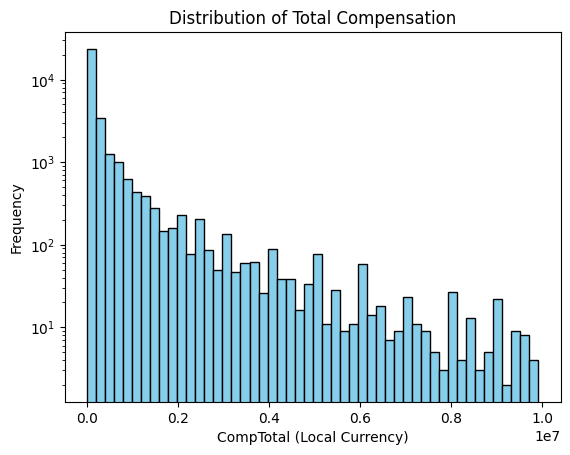

In [51]:
plt.hist(comp_data['CompTotal'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Total Compensation')
plt.xlabel('CompTotal (Local Currency)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

In [52]:
print(comp_data['CompTotal'].describe())

count    3.273300e+04
mean     3.857888e+05
std      9.351785e+05
min      0.000000e+00
25%      5.740000e+04
50%      1.030000e+05
75%      2.200000e+05
max      9.912000e+06
Name: CompTotal, dtype: float64


**Box Plots**

Plot a box plot of Age.


In [58]:
## Write your code here
# Re-connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# Query the Age column
query = "SELECT Age FROM main WHERE Age IS NOT NULL AND Age != ''"
age_data = pd.read_sql_query(query, conn)

conn.close()

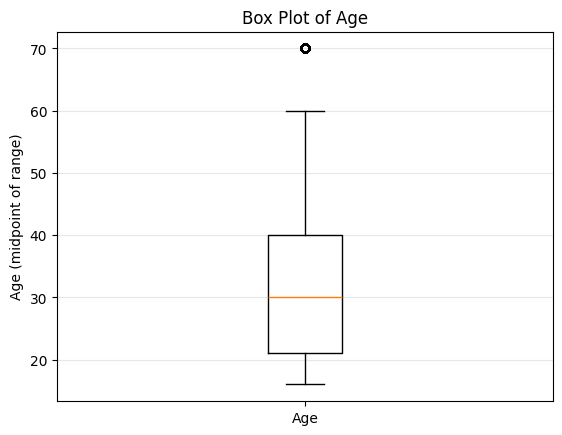

In [61]:
# Age is text, need to treat it as numeric for boxplot
# I convert the age ranges to numeric midpoints for boxplot
# Mapping for Stack Overflow age categories:
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    'Prefer not to say': None
}

# Add mapping and drop None values
numeric_age = age_data['Age'].map(age_mapping).dropna()

# Box plot
plt.boxplot(numeric_age)
plt.title('Box Plot of Age')
plt.ylabel('Age (midpoint of range)')
plt.xticks([1], ['Age'])  
plt.grid(True, axis='y', alpha=0.3)
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


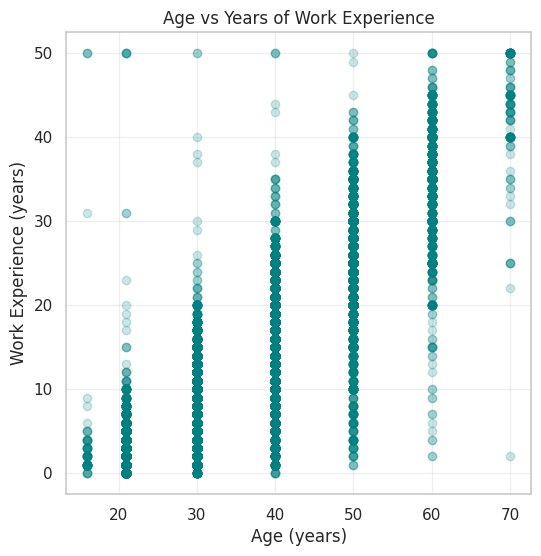

In [103]:
conn = sqlite3.connect('survey-data.sqlite')
query = """
SELECT TimeSearching, Frustration, Age 
FROM main 
WHERE TimeSearching IS NOT NULL 
  AND Frustration IS NOT NULL 
  AND Age IS NOT NULL 
  AND Age != '' 
  AND Age != 'Prefer not to say'
"""
data = pd.read_sql_query(query, conn)
conn.close()
plt.figure(figsize=(6, 6))
plt.scatter(scatter_data['Age'], scatter_data['WorkExp'], alpha=0.2, color='teal')
plt.title('Age vs Years of Work Experience')
plt.xlabel('Age (years)')
plt.ylabel('Work Experience (years)')
plt.grid(True, alpha=0.3)
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [115]:
#conn = sqlite3.connect('survey-data.sqlite')

# Query distinct Frustration values (sorted for readability)
#query = """SELECT DISTINCT Frustration FROM main WHERE Frustration IS NOT NULL ORDER BY Frustration"""
#unique_frust = pd.read_sql_query(query, conn)['Frustration'].tolist()

#conn.close()

#print("All unique Frustration labels:")
#for label in unique_frust:
   #print("- " + label)

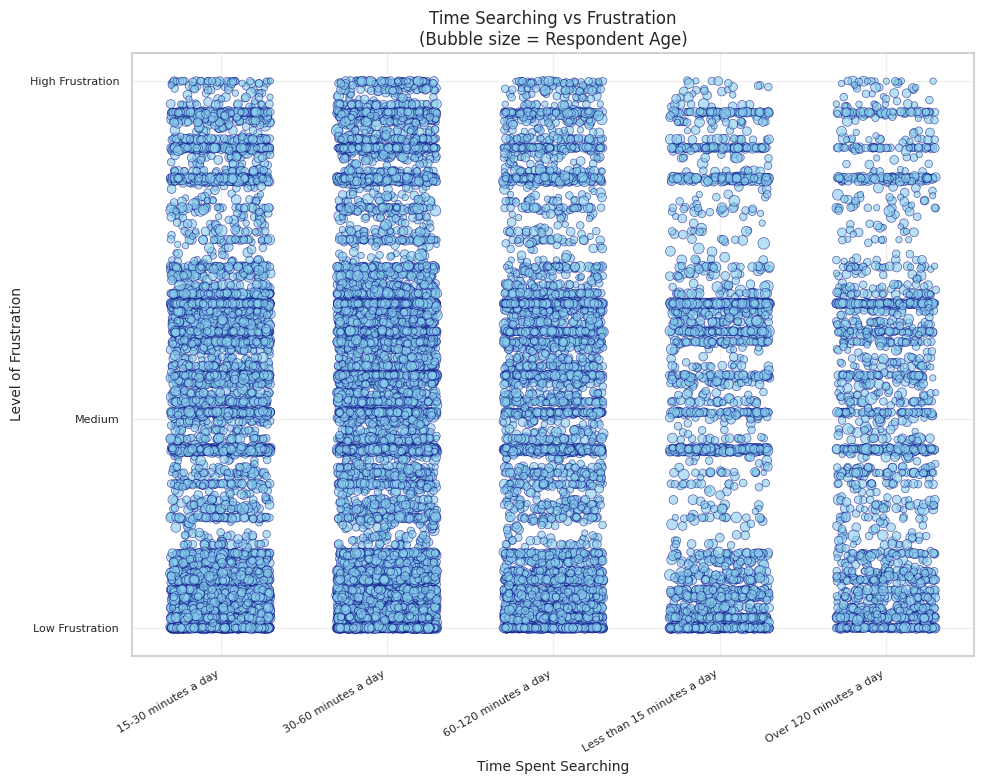

In [123]:
conn = sqlite3.connect('survey-data.sqlite')
query = """
SELECT TimeSearching, Frustration, Age
FROM main
WHERE TimeSearching IS NOT NULL
  AND Frustration IS NOT NULL
  AND Age IS NOT NULL
  AND Age != ''
  AND Age != 'Prefer not to say'
"""
df = pd.read_sql_query(query, conn)
conn.close()

# Map Age to numeric midpoint for bubble size
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}
df['Age_num'] = df['Age'].map(age_map)

# Convert TimeSearching and Frustration to categorical codes + small jitter
df['Time_cat'] = pd.Categorical(df['TimeSearching'])
df['Frust_cat'] = pd.Categorical(df['Frustration'])

df['Time_pos'] = df['Time_cat'].cat.codes
df['Frust_pos'] = df['Frust_cat'].cat.codes

# Add small random jitter to avoid perfect overlap
np.random.seed(42)
df['Time_jitter'] = df['Time_pos'] + np.random.uniform(-0.3, 0.3, size=len(df))
df['Frust_jitter'] = df['Frust_pos'] + np.random.uniform(-0.3, 0.3, size=len(df))

# Bubble size based on Age
bubble_size = df['Age_num']   # scale for visibility

# Create the bubble plot
plt.figure(figsize=(10, 8))
plt.scatter(df['Time_jitter'], df['Frust_jitter'],
            s=bubble_size,
            alpha=0.6,
            color='skyblue',
            edgecolors='navy',
            linewidth=0.5)

# Customize axes with readable labels
time_labels = df['Time_cat'].cat.categories
frust_labels = ['Short', 'Medium', 'Long/Complex']  # simplified for clarity — too many unique combos

plt.xticks(ticks=range(len(time_labels)), labels=time_labels, rotation=30, ha='right', fontsize=8)
plt.yticks(ticks=[df['Frust_pos'].min(), df['Frust_pos'].mean(), df['Frust_pos'].max()],
           labels=['Low Frustration', 'Medium', 'High Frustration'], fontsize=8)

plt.title('Time Searching vs Frustration\n(Bubble size = Respondent Age)', fontsize=12)
plt.xlabel('Time Spent Searching', fontsize=10)
plt.ylabel('Level of Frustration', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


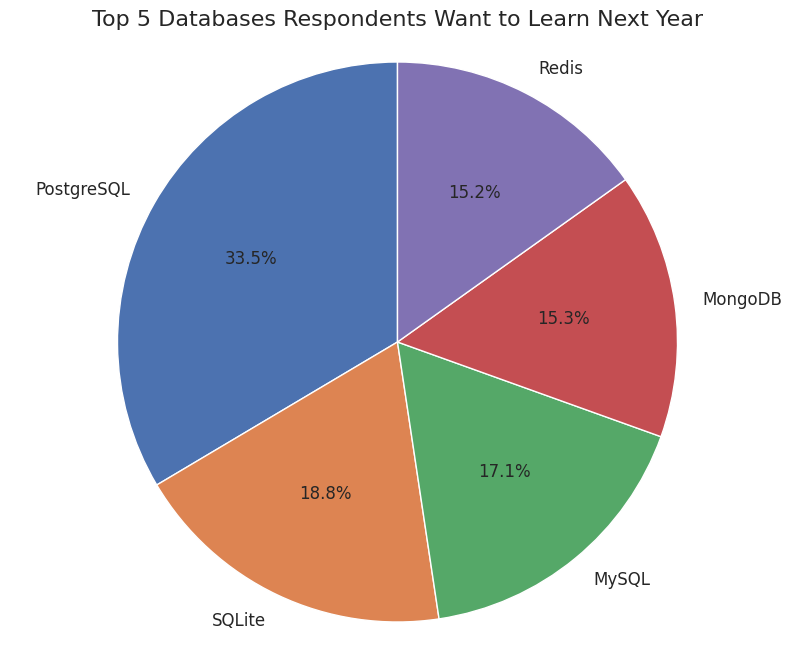

In [124]:
## Write your code here
conn = sqlite3.connect('survey-data.sqlite')

# Get the DatabaseWantToWorkWith column
query = "SELECT DatabaseWantToWorkWith FROM main"
df = pd.read_sql_query(query, conn)
conn.close()

# Drop missing values
df = df.dropna(subset=['DatabaseWantToWorkWith'])

# Split the semicolon-separated values and count each database
databases = df['DatabaseWantToWorkWith'].str.split(';', expand=True).stack()

# Get the top 5 most wanted databases
top5 = databases.value_counts().head(5)

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(top5, 
        labels=top5.index, 
        autopct='%1.1f%%',   # Show percentages
        startangle=90,
        textprops={'fontsize': 12})

plt.title('Top 5 Databases Respondents Want to Learn Next Year', fontsize=16)
plt.axis('equal')  # Make it a perfect circle
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


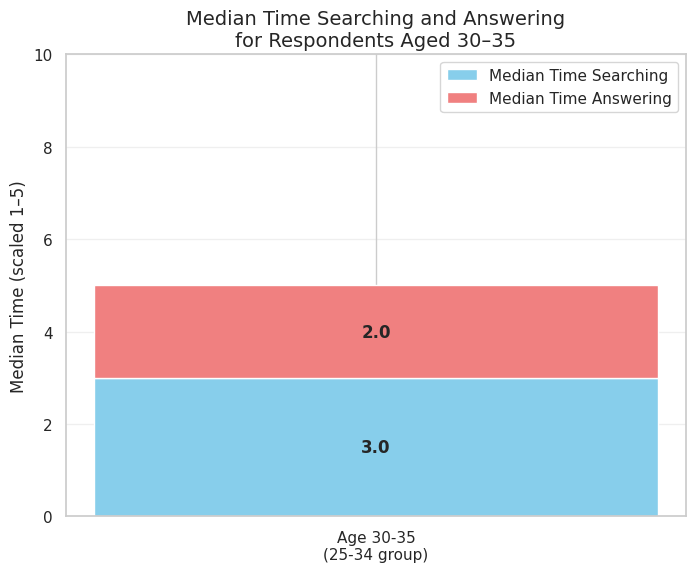

In [127]:
## Write your code here
conn = sqlite3.connect('survey-data.sqlite')

query = """
SELECT TimeSearching, TimeAnswering, Age
FROM main
WHERE Age = '25-34 years old'
  AND TimeSearching IS NOT NULL
  AND TimeAnswering IS NOT NULL
"""
df = pd.read_sql_query(query, conn)
conn.close()

time_map = {
    'Less than 15 minutes a day': 1,
    '15-30 minutes a day': 2,
    '30-60 minutes a day': 3,
    '1-2 hours a day': 4,
    'More than 2 hours a day': 5
}

df['TimeSearching_num'] = df['TimeSearching'].map(time_map)
df['TimeAnswering_num'] = df['TimeAnswering'].map(time_map)

df = df.dropna(subset=['TimeSearching_num', 'TimeAnswering_num'])

# Calculate medians
median_searching = df['TimeSearching_num'].median()
median_answering = df['TimeAnswering_num'].median()

# Data for stacked bar
categories = ['Age 30-35\n(25-34 group)']
searching = [median_searching]
answering = [median_answering]

plt.figure(figsize=(8, 6))

plt.bar(categories, searching, label='Median Time Searching', color='skyblue')
plt.bar(categories, answering, bottom=searching, label='Median Time Answering', color='lightcoral')

plt.text(0, median_searching/2, f'{median_searching:.1f}', ha='center', va='center', fontweight='bold')
plt.text(0, median_searching + median_answering/2, f'{median_answering:.1f}', ha='center', va='center', fontweight='bold')

plt.ylabel('Median Time (scaled 1–5)')
plt.title('Median Time Searching and Answering\nfor Respondents Aged 30–35', fontsize=14)
plt.legend()
plt.ylim(0, 10)  # Give some room
plt.grid(True, axis='y', alpha=0.3)
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


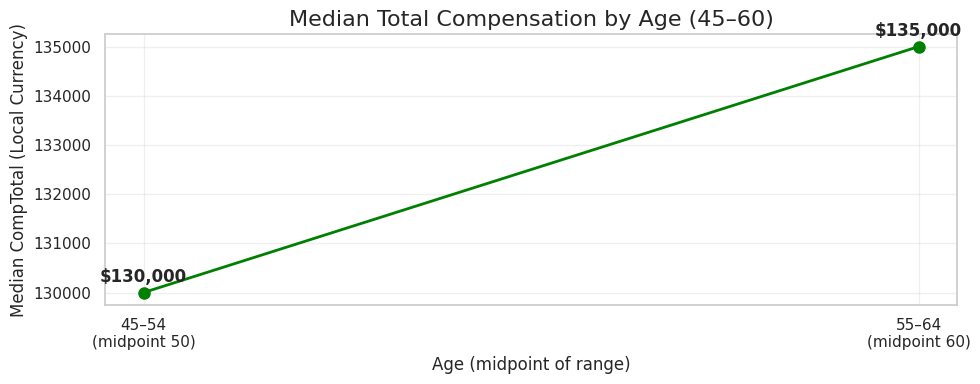

In [139]:
## Write your code here
conn = sqlite3.connect('survey-data.sqlite')

# Query CompTotal and Age, filtering for the relevant age groups
query = """
SELECT CompTotal, Age
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(query, conn)
conn.close()

age_midpoint = {
    '45-54 years old': 50,
    '55-64 years old': 60
}
df['Age_mid'] = df['Age'].map(age_midpoint)

# Group by age midpoint and calculate median CompTotal
median_comp = df.groupby('Age_mid')['CompTotal'].median()

# Prepare data for line chart
ages = median_comp.index.tolist()        # [50, 60]
medians = median_comp.values.tolist()    # median values

# Create the line chart
plt.figure(figsize=(10, 4))
plt.plot(ages, medians, marker='o', linestyle='-', color='green', linewidth=2, markersize=8)

offset = max(medians) * 0.001  # Small offset: 1% of the max value (~$1350 here)

for age, med in zip(ages, medians):
    plt.text(age, med + offset, f'${med:,.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Median Total Compensation by Age (45–60)', fontsize=16)
plt.xlabel('Age (midpoint of range)', fontsize=12)
plt.ylabel('Median CompTotal (Local Currency)', fontsize=12)
plt.grid(True, alpha=0.3)

# X-axis labels
plt.xticks(ages, ['45–54\n(midpoint 50)', '55–64\n(midpoint 60)'])

plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


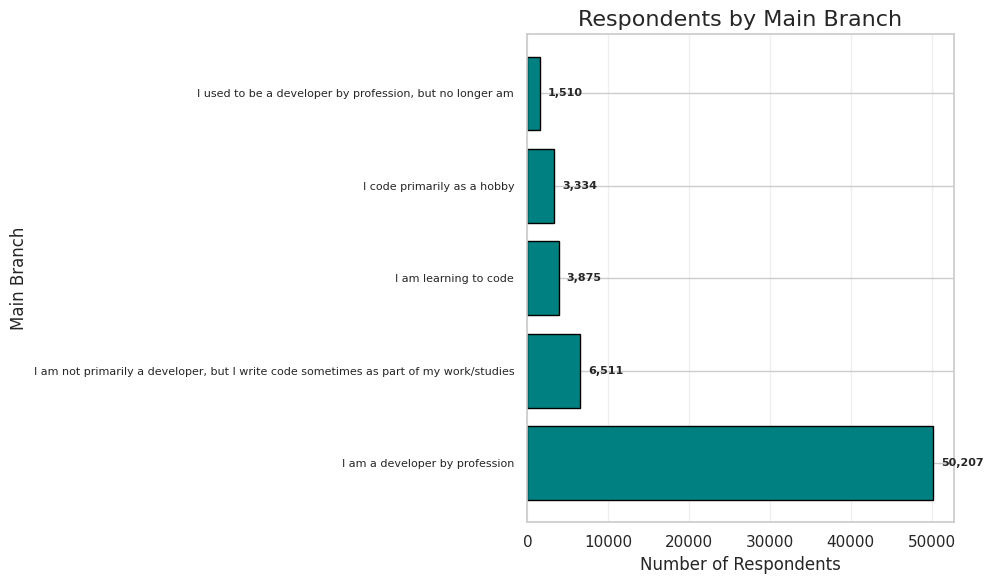

In [152]:
## Write your code here
conn = sqlite3.connect('survey-data.sqlite')

query = """
SELECT MainBranch
FROM main
WHERE MainBranch IS NOT NULL
  AND MainBranch != ''
"""
df = pd.read_sql_query(query, conn)
conn.close()

# Count the occurrences of each MainBranch category
mainbranch_counts = df['MainBranch'].value_counts()

# Create the horizontal bar chart
plt.figure(figsize=(10, 6))

# Plot horizontal bars
plt.barh(mainbranch_counts.index, mainbranch_counts.values, color='teal', edgecolor='black')

# Add value labels on the end of each bar
for i, (branch, count) in enumerate(mainbranch_counts.items()):
    plt.text(count + 1000, i, f'{count:,}', va='center', fontsize=8, fontweight='bold')

plt.title('Respondents by Main Branch', fontsize=16)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Main Branch', fontsize=12)
plt.yticks(fontsize=8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [153]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
